# Анализ имеющихся данных за осень 2023, весну 2024 и осень 2024

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [1]:
'Привет'.split('[')

['Привет']

## Исследование данных по проектам

Рассмотрим данные по предлагаемым проектам.

In [20]:
projects_fall_df = pd.read_csv(r'data/Список проектов - 2023.csv')
projects_fall_df.head()

,Название,Описание,Требования проекта,Требования к исполнителям,Заказчик,Куратор проекта,Контактная информация Заказчика
0,Модуль планирования расходных материалов,"Каждая медицинская услуга, оказываемая учрежде...","Разработать концепцию работы модуля, интерфейс...",Знание базовых основ построения веб-сервисов и...,"Компания ""Виста""",Блеканов И.С.,"Лазебникова Полина, 89148700715, qqpln@mail.ru\n"
1,Личный кабинет пациента,Пациенты довольно часто обращаются в медицинск...,Разработать концепцию работы личного кабинета ...,Знание базовых основ построения веб-сервисов и...,"Компания ""Виста""",Блеканов И.С.,"Лазебникова Полина, 89148700715, qqpln@mail.ru"
2,Смарт-клиника,Работа главного врача связана с частым сбором ...,1. Разработать концепцию работы “Рабочего стол...,"""Знание базовых основ построения веб-сервисов ...","Компания ""Виста""",Блеканов И.С.,"Лазебникова Полина, 89148700715, qqpln@mail.ru\n"
3,Детектирование аорты сердца на снимках КТ,Существуют сложные случаи сердечно-сосудистых ...,1. Разработать модель глубокого обучения для с...,● Знание базовых основ построения веб-сервисов...,Клиника высоких медицинских технологий им. Н.И...,"И.С. Блеканов, Коваленко Лев","И.С. Блеканов, Лев Коваленко, Ким Глеб"
4,Геоинформационная система для точного земледелия,Для реализации цифрового двойника в умном раст...,"""1. Разработать концепцию единого Веб-сервиса,...",●Знание базовых основ построения веб-сервисов ...,Агрофизический институт,"И.С. Блеканов, Лев Коваленко","Митрофанов Евгений Павлович, +79817597773, mje..."


In [19]:
projects_spring_df = pd.read_csv(r'data/Список проектов ТП - весна 2024.csv')
projects_spring_df.head()

,Название,Описание,Требования проекта,Требования к исполнителям,Заказчик,Куратор проекта,Контактная информация Заказчика
0,Модуль отладки динамического поведения графиче...,Имеется набор графических 3х-мерных объектов с...,Клиент отображения (сцена виртуальной реальнос...,Требования:\n - навыки программирования на С++...,Росатом,"Блеканов И.С., Орехов М.Ю.","Михаил Юрьевич Орехов, \nТелеграм (доступен по..."
1,Автоматическая цветовая коррекция,Автоматическая цветовая коррекция необходима д...,1.\tВ реализации алгоритма не должны применятс...,"1.\tПонимание технологий WebGL, JavaScript, Ca...",СТЦ,И.С. Блеканов,"Алексей,\nТелеграм: @komalmex"
2,Алгоритм Retinex,Целью данного проекта является разработка и ре...,1.\tВ реализации алгоритма не должны применятс...,"1.\tПонимание принципов работы с WebGL, JavaSc...",СТЦ,И.С. Блеканов,"Алексей,\nТелеграм: @komalmex"
3,Интеллектуальное возвращение БпЛА в точку стар...,"Проект посвящён управлению БпЛА, оснащённого к...",1. Система должна автоматически начинать свою ...,Язык программирования: С++\nПрограммирование e...,Гескан,И.С. Блеканов,Матросов Валерий Витальевич. Руководитель отде...
4,Автоматизация сбора и обработки пространственн...,В мире существует не только большое количество...,"Ожидаемый результат:\nАртефакты, использование...",Умение или готовность к быстрому освоению рабо...,Центра аналитики динамических процессов и сист...,С.Ю. Севрюков,Профессор А.Ю. Крылатов


После рассмотрения проектных описаний можно сделать следующие выводы:

При подборе команд можно использовать информацию по описанию проекта и требованию к исполнителям. Из описания можно с помощью средств nlp (суммаризация, NER, LLM) вычленить основную информацию по проекту.  Можно использовать LLM для автоматизации составления описания проекта в определенном формате, оценке необходимых компетенций и их ранжирование, таким образом мы можем получить категориальные фичи. В целом LLM может помочь сформулировать требования по проекту в более формализованном виде. Также из требований к исполнителям можем вытащить основные hard-skills. В целом можно и изменить анкету для проектов, путем упрощения задания необходимых компетенций тоглами либо выбором компетенций из списка. Также можно попросить заказчика оценить требования к скиллам по различным направлениям (frontend, backend, ds, devops и т.д.), однако это может быть затруднительной задачей для заказчика, поэтому в целях автоматизации процесса скорее всего лучше использовать LLM. 

## Анкеты исполнителей.

Перейдем к рассмотрению статистики по анкетам исполнителей. Посмотрим на используемые фичи.

Осень 2023

In [33]:
df_fall_2023 = pd.read_excel(r'data/Анкета - осень 23 (Ответы).xlsx')

In [34]:
features = list(df_fall_2023.columns)
for feature in features:
    print(feature)

Отметка времени
Фамилия Имя Отчество
Единая учетная запись СПбГУ (например, ST000000)
Ваша программа подготовки
Контактная информация для оперативной обратной связи в telegram: @login
Выберете интересующие Вас роли, в  IT [Бизнес и системный анализ]
Выберете интересующие Вас роли, в  IT [Дизайн UX / UI и проектирование интерфейсов]
Выберете интересующие Вас роли, в  IT [Анализ и инженерия данных]
Выберете интересующие Вас роли, в  IT [Backend - разработка]
Выберете интересующие Вас роли, в  IT [Frontend - разработка]
Выберете интересующие Вас роли, в  IT [Тестирование и обеспечение качества]
Выберете интересующие Вас роли, в  IT [Развертывание и внедрение]
Выберете интересующие Вас роли, в  IT [Управление командой / проектом]
Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Разработка веб-сервисов (сайты, сервисы)]
Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анал

Весна 2024

In [35]:
df_spring_2024 = pd.read_excel(r'data/Анкета - весна 24 (Ответы).xlsx')

In [36]:
features = list(df_spring_2024.columns)
for feature in features:
    print(feature)

Отметка времени
Фамилия Имя Отчество
Единая учетная запись СПбГУ (например, ST000000)
Ваша программа подготовки
Контактная информация для оперативной обратной связи в telegram: @login
Выберете интересующие Вас роли, в  IT [Бизнес и системный анализ]
Выберете интересующие Вас роли, в  IT [Дизайн UX / UI и проектирование интерфейсов]
Выберете интересующие Вас роли, в  IT [Анализ и инженерия данных]
Выберете интересующие Вас роли, в  IT [Backend - разработка]
Выберете интересующие Вас роли, в  IT [Frontend - разработка]
Выберете интересующие Вас роли, в  IT [Тестирование и обеспечение качества]
Выберете интересующие Вас роли, в  IT [Развертывание и внедрение]
Выберете интересующие Вас роли, в  IT [Управление командой / проектом]
Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Разработка веб-сервисов (сайты, сервисы)]
Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анал

Осень 2024

In [37]:
df_fall_2024 = pd.read_excel(r'data/Contact Information (Responses) (0сень 2024).xlsx')

In [38]:
features = list(df_fall_2024.columns)
for feature in features:
    print(feature)

Timestamp
Фамилия Имя Отчество
Логин Github
Контактная информация для оперативной обратной связи в https://vk.com/id0
Контактная информация для оперативной обратной связи в telegram: @login
Выберете интересующие Вас роли, в  IT [Бизнес и системный анализ]
Выберете интересующие Вас роли, в  IT [Дизайн UX / UI и проектирование интерфейсов]
Выберете интересующие Вас роли, в  IT [Анализ и инженерия данных]
Выберете интересующие Вас роли, в  IT [Backend - разработка]
Выберете интересующие Вас роли, в  IT [Frontend - разработка]
Выберете интересующие Вас роли, в  IT [Тестирование и обеспечение качества]
Выберете интересующие Вас роли, в  IT [Развертывание и внедрение]
Выберете интересующие Вас роли, в  IT [Управление командой / проектом]
Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Разработка веб-сервисов (сайты, сервисы)]
Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше)

В анкетах категории за все сезоны примерно одинаковые. 

Роли и направления у нас в формате категориальных переменных (3 варианта), можно в целом в будущем перевести в численные значения, чем выше заинтересованность, тем больше значение. Оценку знаний по областям можем также оставить в виде числовой переменной - чем выше оценка, тем выше навык. При автоматизации будет сложно учитывать уже существующие проекты участников, но в целом может быть также можно по описанию классифицировать проект по тематикам, либо просто предложить пользователю тематику проекта, в котором он участвовал. Фичи с библиотеками и фреймворками можно сделать бинарными, либо применить здесь также векторное представление на основе nlp, далее можем как то близость считать, хотя скорее всего это избыточно, но в теории можно. Аналитические навыки и софт скиллы также можно оставить численными переменными. Можно отдельно допом как-то использовать пм-овские аналитические и софт скилльные навыки (как то аггрегировать пункты с декомпозицией задач, планированием деятельности, ведением документации, управлением людьми). Открытые вопросы будет сложно интерпретировать автоматически. Также можно как-то ставить оценку после nlp анализа. Мотивацию оставим в виде численного признака.

 Нужно добавить фичи с непосредственным опытом(как на хх, меньше года, 1-3, 3-6 или т.п.), но тут тогда также надо будет учитывать область, в которой работал человек + добавить бинарный уровень образования(в нашем случае бак./маг.).

## Минимальная статистика по данным

Посмотрим примерную статистику по участникам 

Функция для столбчатой диаграммы статистики по ролям:

In [109]:
def plot_role_stat(df: pd.DataFrame):
    labels = ['Выберете интересующие Вас роли, в  IT [Бизнес и системный анализ]',
    'Выберете интересующие Вас роли, в  IT [Дизайн UX / UI и проектирование интерфейсов]',
    'Выберете интересующие Вас роли, в  IT [Анализ и инженерия данных]',
    'Выберете интересующие Вас роли, в  IT [Backend - разработка]',
    'Выберете интересующие Вас роли, в  IT [Frontend - разработка]',
    'Выберете интересующие Вас роли, в  IT [Тестирование и обеспечение качества]',
    'Выберете интересующие Вас роли, в  IT [Развертывание и внедрение]',
    'Выберете интересующие Вас роли, в  IT [Управление командой / проектом]']

    new_labels = ['Б/C анализ', 'Дизайн (UX/UI)', 'DS/DE','Backend', 'Frontend', 'QA', 'devOps', 'PM']

    X_axis = np.arange(len(labels))

    values = ['Не интересно', 'Интересно, можно попробовать', 'Хочу поучаствовать в проекте в этой роли и развиваться дальше в эту область']
    X1 = []
    X2 = []
    X3 = []

    for label in labels:
        data = df[label].value_counts()
        X1.append(data[values[0]])
        X2.append(data[values[1]])
        X3.append(data[values[2]])

    width = 0.2
    multiplier = 0

    plt.figure(figsize=(12, 5))
    plt.bar(X_axis - 0.2, X1, 0.2, label = 'не интересно') 
    plt.bar(X_axis, X2, 0.2, label = 'можно попробовать')
    plt.bar(X_axis + 0.2, X3, 0.2, label = 'хочу развиваться')
    for i in range(len(labels)):
        plt.text(X_axis[i] - 0.3, X1[i], X1[i])
        plt.text(X_axis[i] - 0.1, X2[i], X2[i])
        plt.text(X_axis[i] + 0.1, X3[i], X3[i])
    plt.xticks(X_axis, new_labels) 
    plt.xlabel("roles") 
    plt.ylabel("Number of Students") 
    plt.title("Number of Students for each role") 
    plt.legend() 
    plt.show()

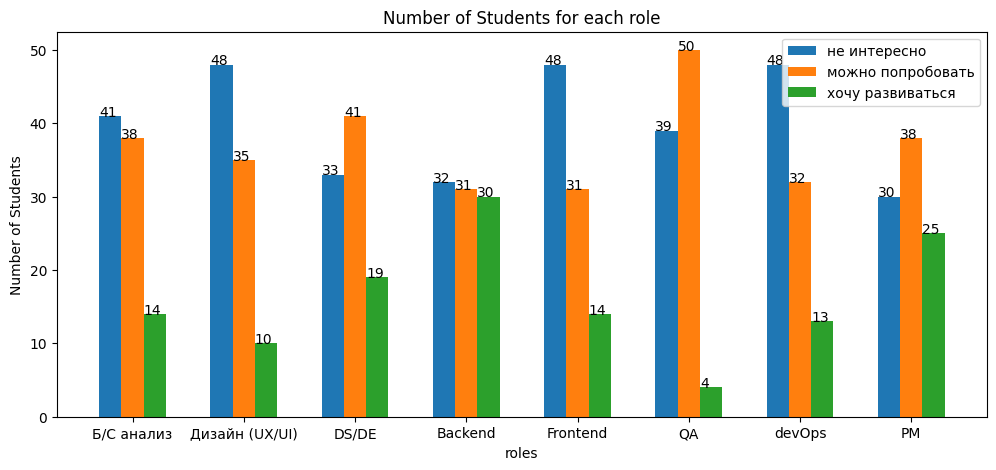

In [110]:
plot_role_stat(df_fall_2023)

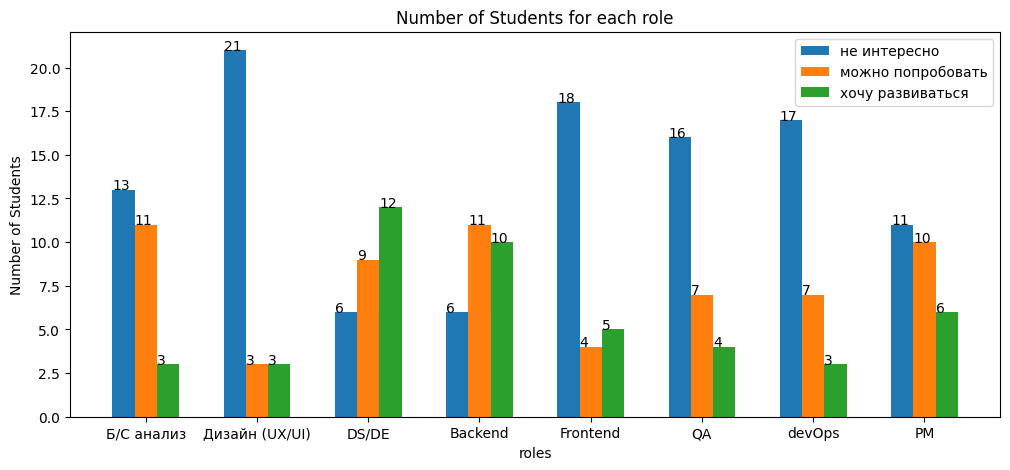

In [111]:
plot_role_stat(df_spring_2024)

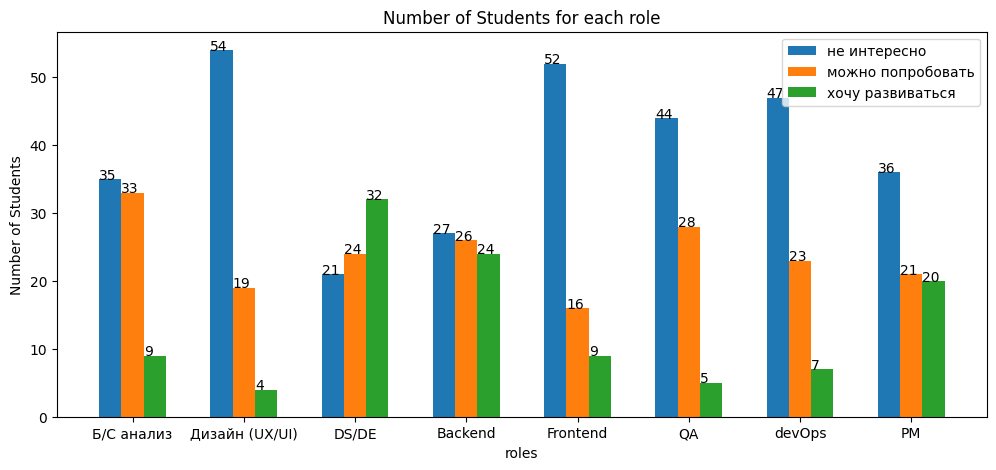

In [112]:
plot_role_stat(df_fall_2024)

По статистике, дизайн, devops, QA - самые непопулярные роли. Тех, кто хочет больше развиваться в этих областях возможно лучше разбивать сразу на самые требовательные проекты в этой области. Нужно как-то учитывать, что в определенном проекте важнее иметь человека с мало-популярной ролью.

Статистика по интересующим направлениям

In [ ]:
labels = ['Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Разработка веб-сервисов (сайты, сервисы)]',
'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анализ текстов и поисковые движки]',
'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анализ изображений / видео]',
'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анализ временных рядов]',
'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анализ табличных данных]',
'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Робототехника (оборудование, теория управления, техническое зрение, интерфейсы)]',
'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Gamedev]']

In [121]:
def plot_proj_stat(df: pd.DataFrame):
    labels = ['Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Разработка веб-сервисов (сайты, сервисы)]',
    'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анализ текстов и поисковые движки]',
    'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анализ изображений / видео]',
    'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анализ временных рядов]',
    'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Анализ табличных данных]',
    'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Робототехника (оборудование, теория управления, техническое зрение, интерфейсы)]',
    'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Gamedev]']

    new_labels = ['Web', 'NLP and Search Engine', 'Image/Video Data', 'Time Series', 'Table Data','Robototechnics', 'GameDev']

    X_axis = np.arange(len(labels))

    values = ['Не интересно', 'Интересно, можно попробовать', 'Хочу поучаствовать в проекте по данной области в роли, выбранной ранее']
    X1 = []
    X2 = []
    X3 = []

    for label in labels:
        data = df[label].value_counts()
        X1.append(data[values[0]])
        X2.append(data[values[1]])
        X3.append(data[values[2]])

    width = 0.2
    multiplier = 0

    plt.figure(figsize=(15, 5))
    plt.bar(X_axis - 0.2, X1, 0.2, label = 'не интересно') 
    plt.bar(X_axis, X2, 0.2, label = 'можно попробовать')
    plt.bar(X_axis + 0.2, X3, 0.2, label = 'хочу поучавствовать')
    for i in range(len(labels)):
        plt.text(X_axis[i] - 0.3, X1[i], X1[i])
        plt.text(X_axis[i] - 0.1, X2[i], X2[i])
        plt.text(X_axis[i] + 0.1, X3[i], X3[i])
    plt.xticks(X_axis, new_labels) 
    plt.xlabel("roles") 
    plt.ylabel("Number of Students") 
    plt.title("Number of Students for each area") 
    plt.legend() 
    plt.show()

Осень 2023

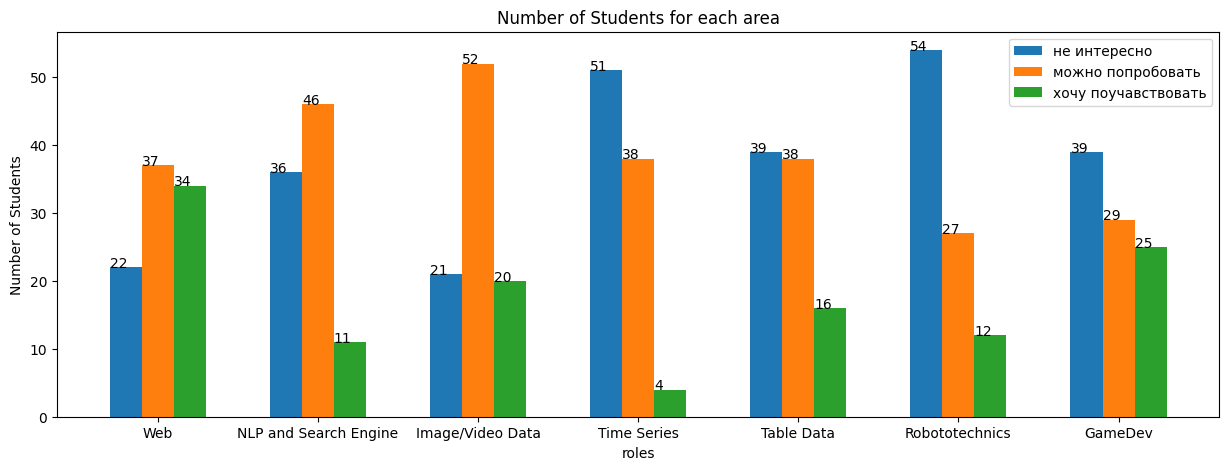

In [122]:
plot_proj_stat(df_fall_2023)

Весна 2024

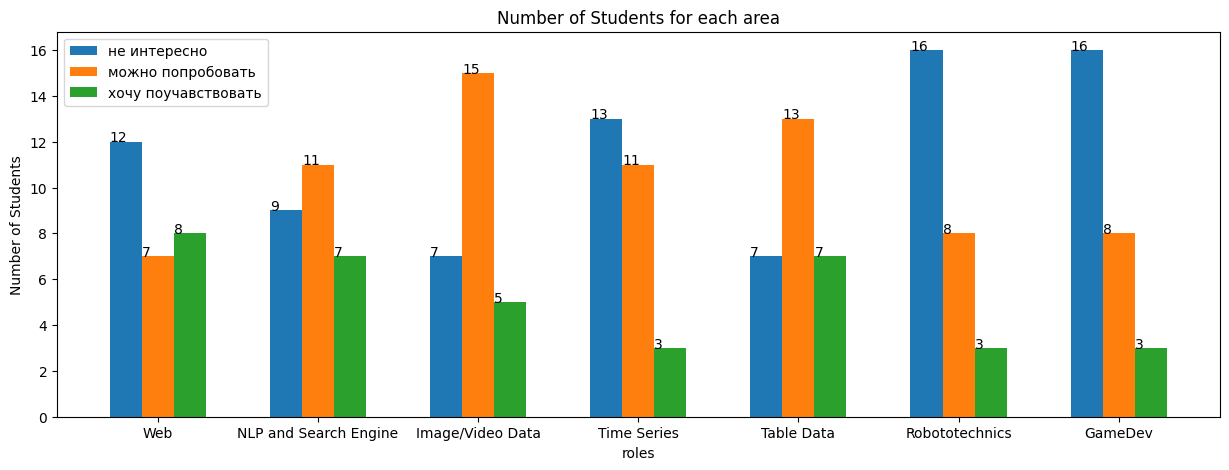

In [124]:
plot_proj_stat(df_spring_2024)

Осень 2024

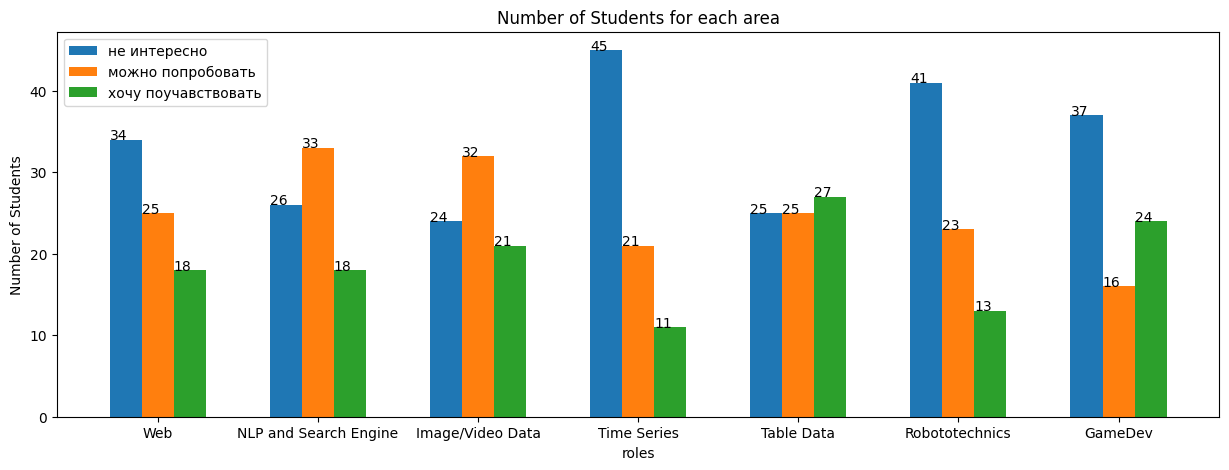

In [125]:
plot_proj_stat(df_fall_2024)

Наименее популярные проекты связаны с TimeSeries, nlp и робототехникой, желательно также распределять основное число желающих в первую очередь на эти направления.

## функция для предобработки csv в json

In [7]:
import pandas as pd
from copy import deepcopy

def csv_to_json(data: pd.DataFrame) -> dict:
    
    base_dict = {
      "id": 179,
      "name": "Жернильский Святослав Михайлович",
      "form": {
        "formId": "1",
        "data": [
          {
            "type": "DEFAULT",
            "question": "Timestamp",
            "answer": ""
          },
          {
            "type": "DEFAULT",
            "question": "Фамилия Имя Отчество",
            "answer": "Жернильский Святослав Михайлович"
          },
          {
            "type": "DEFAULT",
            "question": "Логин Github",
            "answer": ""
          },
          {
            "type": "DEFAULT",
            "question": "Контактная информация для оперативной обратной связи в https://vk.com/id0",
            "answer": ""
          },
          {
            "type": "DEFAULT",
            "question": "Контактная информация для оперативной обратной связи в telegram: @login",
            "answer": "@slavikslavikslavikslavik"
          },
          {
            "type": "GRID",
            "question": "Выберете интересующие Вас роли, в  IT ",
            "answers": [
            ],
            "rows": [
              "Бизнес и системный анализ",
              "Дизайн UX / UI и проектирование интерфейсов",
              "Анализ и инженерия данных",
              "Backend - разработка",
              "Frontend - разработка",
              "Тестирование и обеспечение качества",
              "Развертывание и внедрение",
              "Управление командой / проектом"
            ]
          },
          {
            "type": "GRID",
            "question": "Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) ",
            "answers": [
            ],
            "rows": [
              "Разработка веб-сервисов (сайты, сервисы)",
              "Анализ текстов и поисковые движки",
              "Анализ изображений / видео",
              "Анализ временных рядов",
              "Анализ табличных данных",
              "Робототехника (оборудование, теория управления, техническое зрение, интерфейсы)",
              "Gamedev"
            ]
          },
          {
            "type": "DEFAULT",
            "question": "Если в предыдущем вопросе для Вас не было интересного направления деятельности, расскажите нам об области, в которой Вы хотите развиваться"
          },
          {
            "type": "DEFAULT",
            "question": "Если Вы уже работаете над интересным проектом или успешно завершили - опишите, что это за проект и свою роль в нем (можете добавить ссылку на репозиторий)"
          },
          {
            "type": "GRID",
            "question": "Оцените Ваши знания в области IT ",
            "answers": [
            ],
            "rows": [
              "Парадигмы программирования (ООП, функциональное, аспектно-ориентированное, и др.)",
              "Архитектура ПО",
              "Паттерны проектирования",
              "Протоколы коммуникаций (REST, gRPC, и др.)",
              "Алгоритмы и структуры данных",
              "Потоки и параллельность",
              "Linux in dev and administration",
              "Windows in dev and administration",
              "Проектирование и оптимизация баз данных",
              "Data Science and Machine Learning"
            ]
          },
          {
            "type": "DEFAULT",
            "question": "Какими еще знаниями Вы владеете, релевантными для IT-отрасли и в какой степени? Перечислите их и оцените"
          },
          {
            "type": "DEFAULT",
            "question": "Языки программирования (например: C++, Python, Java, etc)",
            "answer": "С++ - 4\r\nPython - 2\r\nC# - 2\r\nPascal - 2"
          },
          {
            "type": "DEFAULT",
            "question": "Библиотеки и фреймворки для различных направлений использования (например: Qt, Numpy, Weka, Angular, PyTorch, etc)",
            "answer": "Numpy - 2\r\nPyTorch - 2"
          },
          {
            "type": "DEFAULT",
            "question": "Инструменты для проектирования, бизнес и системного анализа (например: BPMN, UML, Archimate, ARIS etc)"
          },
          {
            "type": "DEFAULT",
            "question": "Инструменты для разработки ПО - например: VS Code, PyCharm, Git, etc)",
            "answer": "VS Code - 2\r\nPyCharm - 2"
          },
          {
            "type": "DEFAULT",
            "question": "Инструменты для тестирования  (например: GTests, Selenium, Gatling, pytest etc)"
          },
          {
            "type": "DEFAULT",
            "question": "Инструменты CI / CD (например: Jenkins, Travis CI, Docker, etc)"
          },
          {
            "type": "DEFAULT",
            "question": "Инструменты для управления проектами (например: Jira, Trello, MS Project, etc)"
          },
          {
            "type": "GRID",
            "question": "Аналитические навыки ",
            "answers": [
            ],
            "rows": [
              "Поиск информации (научные статьи, документация)",
              "Сбор и анализ требований к ПО",
              "Декомпозиция задач",
              "Планирование своей и чужой деятельности",
              "Тестирование",
              "Ведение документации"
            ]
          },
          {
            "type": "GRID",
            "question": "SoftSkills ",
            "answers": [
            ],
            "rows": [
              "Self management",
              "Коммуникации",
              "Работа в команде",
              "Наставничество",
              "Управление людьми"
            ]
          },
          {
            "type": "DEFAULT",
            "question": "Какими еще навыками в области IT Вы обладаете? Оцените данные навыки"
          },
          {
            "type": "GRID",
            "question": "Оцените Ваш уровень мотивации ",
            "answers": [
              "3 - Готов выполнять задания, но если в них вижу личную выгоду/интерес",
              "3 - Готов выполнять задания, но если в них вижу личную выгоду/интерес",
              "3 - Готов выполнять задания, но если в них вижу личную выгоду/интерес"
            ],
            "rows": [
              "К работе над интересными проектами",
              "Определить свой путь дальнейшего развития и развиваться в IT",
              "Устроиться на интересную для себя работу"
            ]
          },
          {
            "type": "DEFAULT",
            "question": "Хотите ли Вы общаться с другими студентами и выпускниками, заинтересованными в развитии в области IT на базе СПбГУ на интересующие Вас темы?"
          },
          {
            "type": "DEFAULT",
            "question": "Что Вам поможет развиваться быстрее в том направлении деятельности, которое Вы выбрали?",
            "answer": "Интерес, больше свободного времени, больше денег за работу и господь Бог"
          }
        ]
      }
    }
    users_list = []
    for index, row in data.iterrows():
        users_list.append(deepcopy(base_dict))
        users_list[-1]['id'] = index
        users_list[-1]['name'] = row['Фамилия Имя Отчество']
        users_list[-1]['form']['formId'] = index
        for column_name in row.index:
            splitted_column_name = column_name.split('[')
            for question in users_list[-1]['form']['data']:
                if len(splitted_column_name) > 1:
                  if question['question'] == splitted_column_name[0]:
                    question['answers'].append(row[column_name])
                else:
                  if question['question'] == column_name:
                     question['answer'] =  row[column_name]
    return users_list

In [9]:
import pandas as pd

data = pd.read_excel('Учебная_практика_весна_25_Ответы.xlsx')

In [10]:
for index, row in data.iterrows():
    print(type(row))
    break

<class 'pandas.core.series.Series'>


In [11]:
row['Отметка времени']

Timestamp('2025-03-05 10:23:42.691000')

In [12]:
users = csv_to_json(data)

In [13]:
import json
with open(r'C:\Users\Тимур\code\server\demo\demo_input.json', 'r', encoding='utf-8') as f:
    input = json.load(f)

In [14]:
input['data']['users'] = users

In [15]:
import json
with open(r'C:\Users\Тимур\code\server\demo\new_input.json', 'w', encoding='utf-8') as f:
    json.dump(input, f, ensure_ascii=False, indent=4)

In [20]:
data.iloc[0].index

Index(['Отметка времени', 'Фамилия Имя Отчество',
       'Единая учетная запись СПбГУ (например, ST000000)',
       'Ваша программа подготовки',
       'Контактная информация для оперативной обратной связи в telegram: @login',
       'Выберете интересующие Вас роли, в  IT [Бизнес и системный анализ]',
       'Выберете интересующие Вас роли, в  IT [Дизайн UX / UI и проектирование интерфейсов]',
       'Выберете интересующие Вас роли, в  IT [Анализ и инженерия данных]',
       'Выберете интересующие Вас роли, в  IT [Backend - разработка]',
       'Выберете интересующие Вас роли, в  IT [Frontend - разработка]',
       'Выберете интересующие Вас роли, в  IT [Тестирование и обеспечение качества]',
       'Выберете интересующие Вас роли, в  IT [Развертывание и внедрение]',
       'Выберете интересующие Вас роли, в  IT [Управление командой / проектом]',
       'Выберете интересные для вас направление проекта (в направлении проекта могут быть все роли, указанные выше) [Разработка веб-сервисов 